# Demo

## Prepare for the coding environment

In [29]:
# Imports
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import pyogrio
import sys
import subprocess
import warnings
import re
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pathlib import Path
sys.path.append(str(Path.cwd().parent))  # if running from notebooks/
from paths import *

In [2]:
# Install requirement.txt
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-r", "../requirements.txt"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

CompletedProcess(args=['D:\\PythonCode\\python.exe', '-m', 'pip', 'install', '-r', '../requirements.txt'], returncode=0)

## 1. Wrangling

In [6]:
# load in the two data sets
sopp = pd.read_csv(RAW_DATA_PATH / "sopp.csv") # police stop dataset
svi_tab = pd.read_csv(RAW_DATA_PATH / "California.csv")# social vulnerability index dataset

svi_tab = svi_tab[['FIPS', 'RPL_THEMES']].copy() # These are the columns for merging later
svi_tab['FIPS'] = svi_tab['FIPS'].astype(str).str.replace(r'\.0$', '', regex=True) # geographical area identifier

# Preview datasets
print(sopp.head())
print(svi_tab.head())

  raw_row_number        date      time service_area  subject_age  \
0              1  2014-01-01  01:25:00          110         24.0   
1              2  2014-01-01  05:47:00          320         42.0   
2              3  2014-01-01  07:46:00          320         29.0   
3              4  2014-01-01  08:10:00          610         23.0   
4              5  2014-01-01  08:35:00          930         35.0   

             subject_race subject_sex       type arrest_made citation_issued  \
0                   white        male  vehicular       False            True   
1                   white        male  vehicular       False           False   
2  asian/pacific islander        male  vehicular       False           False   
3                   white        male  vehicular       False            True   
4                hispanic        male  vehicular       False            True   

   ...   outcome contraband_found search_conducted  search_person  \
0  ...  citation              NaN        

In [7]:
# Data Wrangling
def wrangle_sopp(df):
    # Example: drop rows with missing stop reason
    return df.dropna(subset=['stop_reason']) if 'stop_reason' in df.columns else df

def wrangle_svi(df):
    # Example: rename column for clarity
    return df.rename(columns={'RPL_THEMES': 'SVI_Score'})

# Apply wrangling
sopp_clean = wrangle_sopp(sopp)
svi_clean = wrangle_svi(svi_tab)

# Preview cleaned datasets
print("\nCleaned Police Stop Data:")
print(sopp_clean.head())
print("\nCleaned SVI Data:")
print(svi_clean.head())


Cleaned Police Stop Data:
  raw_row_number        date      time service_area  subject_age  \
0              1  2014-01-01  01:25:00          110         24.0   
1              2  2014-01-01  05:47:00          320         42.0   
2              3  2014-01-01  07:46:00          320         29.0   
3              4  2014-01-01  08:10:00          610         23.0   
4              5  2014-01-01  08:35:00          930         35.0   

             subject_race subject_sex       type arrest_made citation_issued  \
0                   white        male  vehicular       False            True   
1                   white        male  vehicular       False           False   
2  asian/pacific islander        male  vehicular       False           False   
3                   white        male  vehicular       False            True   
4                hispanic        male  vehicular       False            True   

   ...   outcome contraband_found search_conducted  search_person  \
0  ...  citati

## 2. Processing

In [12]:
# Load in merged dataset
df = pd.read_csv(INT_DATA_PATH / "sopp_svi_merged.csv")

# Preview
df.head()

,Unnamed: 0,raw_row_number,date,time,service_area,subject_age,subject_race,subject_sex,type,arrest_made,...,search_conducted,search_person,search_vehicle,search_basis,reason_for_search,reason_for_stop,raw_action_taken,raw_subject_race_description,serv,svi_rpl_themes
0,0,1,2014-01-01,01:25:00,110,24.0,white,male,vehicular,False,...,False,False,False,NaN,NaN,Moving Violation,Citation,WHITE,110.0,0.241848
1,1,2,2014-01-01,05:47:00,320,42.0,white,male,vehicular,False,...,False,False,False,NaN,NaN,Moving Violation,Verbal Warning,WHITE,320.0,0.213643
2,2,3,2014-01-01,07:46:00,320,29.0,asian/pacific islander,male,vehicular,False,...,False,False,False,NaN,NaN,Moving Violation,Verbal Warning,LAOTIAN,320.0,0.213643
3,3,4,2014-01-01,08:10:00,610,23.0,white,male,vehicular,False,...,False,False,False,NaN,NaN,Moving Violation,Citation,WHITE,610.0,0.121181
4,4,5,2014-01-01,08:35:00,930,35.0,hispanic,male,vehicular,False,...,False,False,False,NaN,NaN,Equipment Violation,Citation,HISPANIC,930.0,0.075382


In [21]:
# Data Processing

# Parse more temporal variables
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["day_of_week"] = df["date"].dt.day_name()

# Print all column names
print(df.columns)

# Preview modified dataset
df.head()

Index(['Unnamed: 0', 'raw_row_number', 'date', 'time', 'service_area',
       'subject_age', 'subject_race', 'subject_sex', 'type', 'arrest_made',
       'citation_issued', 'warning_issued', 'outcome', 'contraband_found',
       'search_conducted', 'search_person', 'search_vehicle', 'search_basis',
       'reason_for_search', 'reason_for_stop', 'raw_action_taken',
       'raw_subject_race_description', 'serv', 'svi_rpl_themes',
       'day_of_week'],
      dtype='object')


,Unnamed: 0,raw_row_number,date,time,service_area,subject_age,subject_race,subject_sex,type,arrest_made,...,search_person,search_vehicle,search_basis,reason_for_search,reason_for_stop,raw_action_taken,raw_subject_race_description,serv,svi_rpl_themes,day_of_week
0,0,1,2014-01-01,01:25:00,110,24.0,white,male,vehicular,False,...,False,False,NaN,NaN,Moving Violation,Citation,WHITE,110.0,0.241848,Wednesday
1,1,2,2014-01-01,05:47:00,320,42.0,white,male,vehicular,False,...,False,False,NaN,NaN,Moving Violation,Verbal Warning,WHITE,320.0,0.213643,Wednesday
2,2,3,2014-01-01,07:46:00,320,29.0,asian/pacific islander,male,vehicular,False,...,False,False,NaN,NaN,Moving Violation,Verbal Warning,LAOTIAN,320.0,0.213643,Wednesday
3,3,4,2014-01-01,08:10:00,610,23.0,white,male,vehicular,False,...,False,False,NaN,NaN,Moving Violation,Citation,WHITE,610.0,0.121181,Wednesday
4,4,5,2014-01-01,08:35:00,930,35.0,hispanic,male,vehicular,False,...,False,False,NaN,NaN,Equipment Violation,Citation,HISPANIC,930.0,0.075382,Wednesday


## 3. EDA

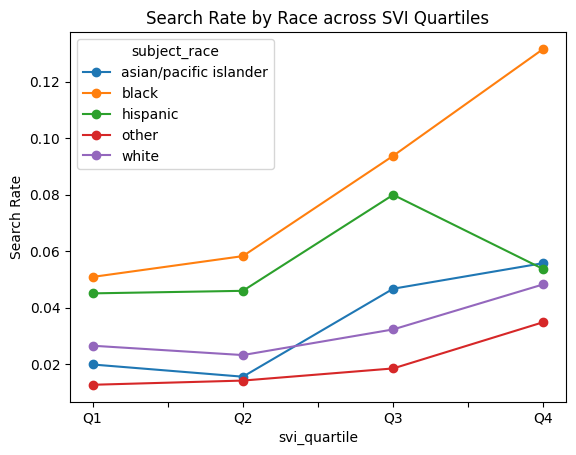

In [26]:
# The pd.qcut splits the 'svi_rpl_themes' into 4 equal-sized bins
df["svi_quartile"] = pd.qcut(df["svi_rpl_themes"], 4, labels=["Q1","Q2","Q3","Q4"])

# Create pivot table
pivot = df.pivot_table(
    values="search_conducted",
    index="svi_quartile",
    columns="subject_race",
    aggfunc="mean",
    observed=False
)

# Plot results
pivot.plot(marker="o")
plt.ylabel("Search Rate")
plt.title("Search Rate by Race across SVI Quartiles")
plt.show()

## 4. modeling

In [34]:
# We chose logistic regression

# Convert search_conducted to numeric 
df["search_conducted"] = df["search_conducted"].astype(int)  # True->1, False->0

# Make categorical variables explicit
df["subject_race"] = df["subject_race"].astype("category")
df["day_of_week"] = df["day_of_week"].astype("category")  # optional

# Fit model (y variable is search conducted, x variables are SVI, race, and day of week)
formula = "search_conducted ~ svi_rpl_themes + C(subject_race) + C(day_of_week)"
logit_model = smf.logit(formula=formula, data=df).fit()

# Show summary
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.170272
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:       search_conducted   No. Observations:               370171
Model:                          Logit   Df Residuals:                   370159
Method:                           MLE   Df Model:                           11
Date:                Mon, 30 Mar 2026   Pseudo R-squ.:                 0.04160
Time:                        22:25:33   Log-Likelihood:                -63030.
converged:                       True   LL-Null:                       -65766.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -3.8496      0.041    -93.720      0.000   

The logistic regression shows that the likelihood of a police search is strongly associated with both the subject’s race and the Social Vulnerability Index (SVI) of the area. 

Black and Hispanic subjects have significantly higher odds of being searched compared to the baseline group, with Black subjects facing nearly three times the odds. 

Higher SVI scores are also strongly predictive, with a one-unit increase in SVI associated with more than a three times increase in the odds of a search, indicating that officers are more likely to search individuals in socially vulnerable areas. 

Day-of-week effects are smaller but significant, with searches slightly more likely on weekends and less likely on certain weekdays. 

Overall, the model suggests that both demographic and contextual factors influence search decisions, and that search rates vary considerably across races and neighborhoods with differing levels of social vulnerability.